In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [88]:
# Load the RFM dataset
DATA_DIR = Path("../data")

rfm = pd.read_csv(DATA_DIR / "olist_rfm.csv")

print(rfm.head())
print(rfm.shape)
print(rfm["churn"].value_counts())
print(rfm["churn"].value_counts(normalize=True))


                 customer_unique_id  recency  frequency  monetary  churn
0  0000366f3b9a7992bf8c76cfdf3221e2      161          1    141.90      0
1  0000b849f77a49e4a4ce2b2a4ca5be3f      164          1     27.19      0
2  0000f46a3911fa3c0805444483337064      586          1     86.22      1
3  0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62      1
4  0004aac84e0df4da2b147fca70cf8255      337          1    196.89      1
(96096, 5)
churn
1    68352
0    27744
Name: count, dtype: int64
churn
1    0.711289
0    0.288711
Name: proportion, dtype: float64


In [90]:

# Define a helper function to train and evaluate model


def run_model(X, y, model_name):
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(class_weight='balanced', max_iter=1000)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    auc = roc_auc_score(y_test, y_prob)
    print(f"AUC-ROC Score: {auc:.4f}")

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(10, 7))
    plt.plot(fpr, tpr, linewidth=2, label=f"Logistic Regression AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=2, label="Random Guess")
    plt.xlabel("False Positive Rate", fontsize=14)
    plt.ylabel("True Positive Rate", fontsize=14)
    plt.title(f"ROC Curve - {model_name}", fontsize=18)
    plt.legend(fontsize=13)
    plt.grid(True)
    plt.show()

    # Return useful model outputs for sigmoid curve
    return {
        "model_name": model_name,
        "model": model,
        "scaler": scaler,
        "X_test_scaled": X_test_scaled,
        "y_prob": y_prob,
        "auc": auc
    }

Model 1 (With Recency)
Confusion Matrix:
[[ 5548     1]
 [  105 13566]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      5549
           1       1.00      0.99      1.00     13671

    accuracy                           0.99     19220
   macro avg       0.99      1.00      0.99     19220
weighted avg       0.99      0.99      0.99     19220

AUC-ROC Score: 1.0000


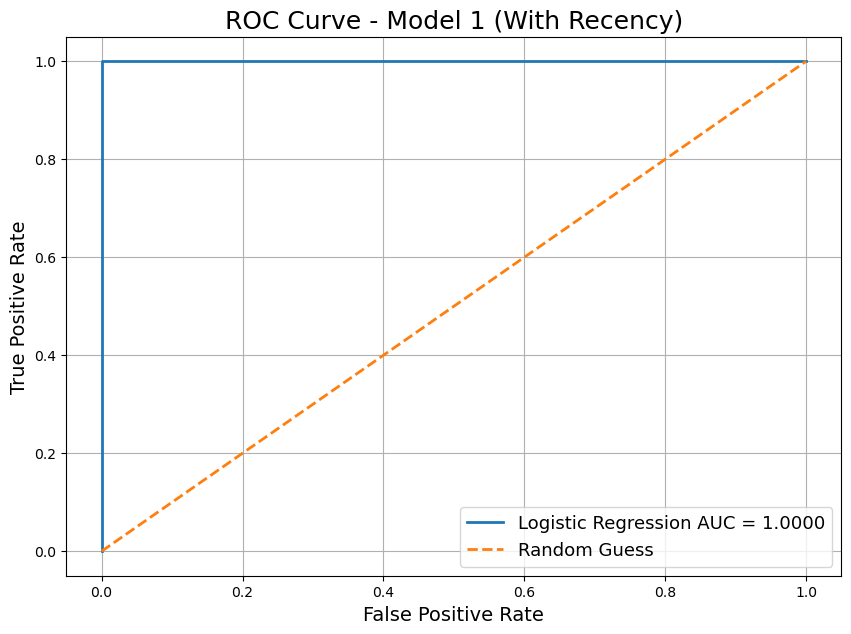

Model 2 (Without Recency)
Confusion Matrix:
[[  382  5167]
 [  869 12802]]

Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.07      0.11      5549
           1       0.71      0.94      0.81     13671

    accuracy                           0.69     19220
   macro avg       0.51      0.50      0.46     19220
weighted avg       0.59      0.69      0.61     19220

AUC-ROC Score: 0.5102


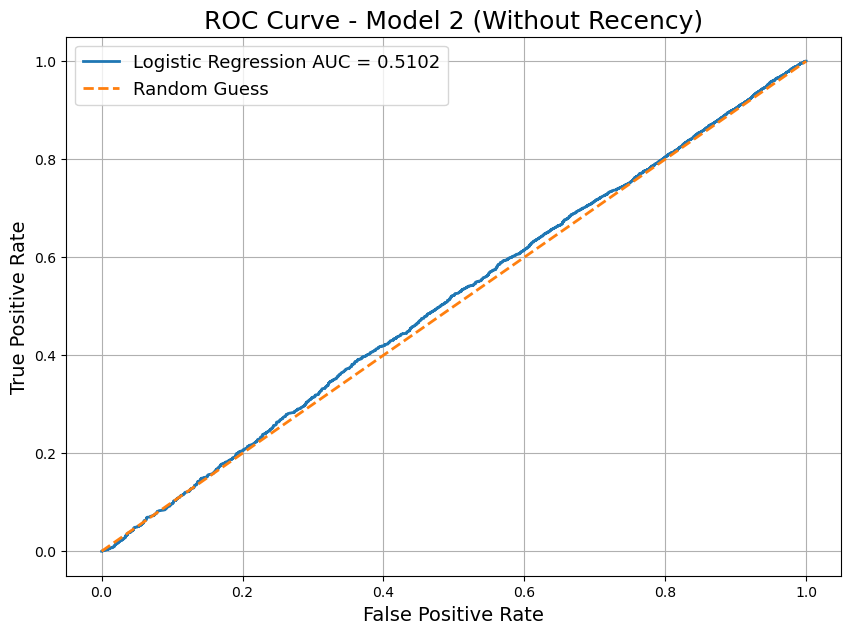

In [91]:

result1 = run_model(
    rfm[['recency', 'frequency', 'monetary']],
    rfm['churn'],
    "Model 1 (With Recency)"
)

result2 = run_model(
    rfm[['frequency', 'monetary']],
    rfm['churn'],
    "Model 2 (Without Recency)"
)

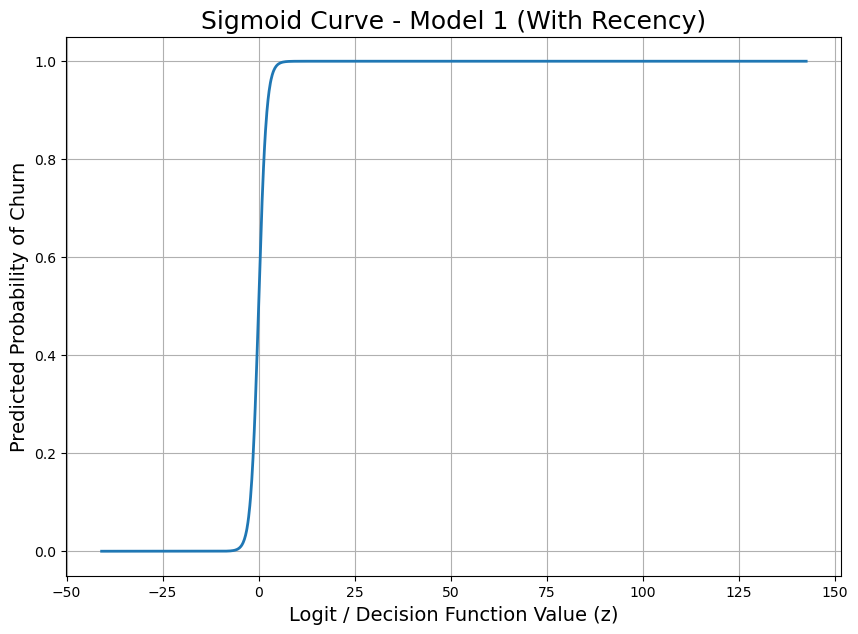

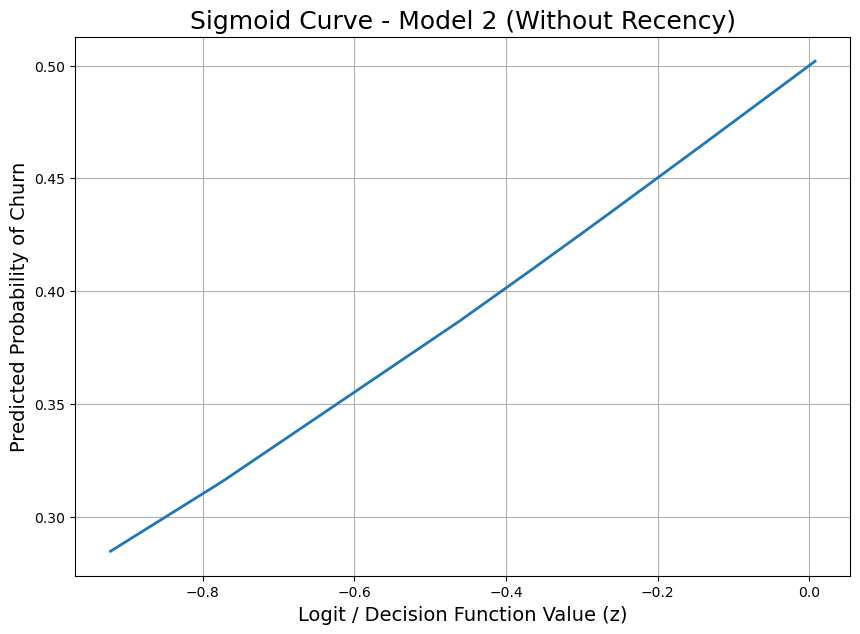

In [92]:


# Sigmoid curves for both logistic regression models

def plot_model_sigmoid(result):
    model = result["model"]
    X_test_scaled = result["X_test_scaled"]
    y_prob = result["y_prob"]
    model_name = result["model_name"]

    # decision_function gives z = wX + b
    z = model.decision_function(X_test_scaled)

    # Sort z values so the curve is smooth
    sorted_idx = np.argsort(z)
    z_sorted = z[sorted_idx]
    prob_sorted = y_prob[sorted_idx]

    plt.figure(figsize=(10, 7))
    plt.plot(z_sorted, prob_sorted, linewidth=2)

    plt.xlabel("Logit / Decision Function Value (z)", fontsize=14)
    plt.ylabel("Predicted Probability of Churn", fontsize=14)
    plt.title(f"Sigmoid Curve - {model_name}", fontsize=18)

    plt.grid(True)
    plt.show()


plot_model_sigmoid(result1)
plot_model_sigmoid(result2)

In [85]:

# Compare results
print("\nModel Comparison: ")
print(f"With Recency AUC: {auc1:.4f}")
print(f"Without Recency AUC: {auc2:.4f}")


Model Comparison:
With Recency AUC: 1.0000
Without Recency AUC: 0.5102
